# Random Forest

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

df = pd.read_csv('../../data/processed/cardio_onc_prostate_04cleaned.csv')
n_folds = 5
seed = 42

## Data Prep

In [2]:
# drop missing target
df = df[df["at_risk"].notna()].copy()

# dataset not fully numeric, but only numeric features are used for modeling
X = df.select_dtypes(include=[np.number]).drop(columns=["at_risk", "unique_patient_id"])
y = df["at_risk"].astype(int).values

print(X.shape)
print(pd.Series(y).value_counts())

(203, 44)
0    124
1     79
Name: count, dtype: int64


## Random Forest Model

In [3]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1
)

### Stratified K-Fold Cross Validation

In [4]:
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    vals = results[f"test_{metric}"]
    print(f"{metric}: {vals.mean():.4f} ± {vals.std():.4f}")

precision: 0.4925 ± 0.0737
recall: 0.4417 ± 0.0998
f1: 0.4591 ± 0.0621
roc_auc: 0.6122 ± 0.0190


## Fit Final Model on Full Data

In [5]:
rf.fit(X,y)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

## Feature Importance

In [6]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
39,days_adt_to_nht,0.124385
0,bmi,0.084695
25,dm_noninsulin,0.083078
38,days_auth_to_start,0.071466
1,age,0.068093
6,dbp,0.056053
5,sbp,0.050753
7,bp_meds_prior,0.048090
43,prescribing_provider_enc,0.044227
40,ethnicity_enc,0.041987


In [7]:
perm_importance = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values("importance", ascending=False)

perm_df.head(15)

,feature,importance,std
25,dm_noninsulin,0.085222,0.006251
39,days_adt_to_nht,0.060099,0.012026
0,bmi,0.033005,0.005419
38,days_auth_to_start,0.027586,0.007373
7,bp_meds_prior,0.023645,0.011405
15,lipid_panel_checked,0.017734,0.009901
1,age,0.016256,0.008258
43,prescribing_provider_enc,0.014778,0.007943
6,dbp,0.014286,0.006013
5,sbp,0.012808,0.006308


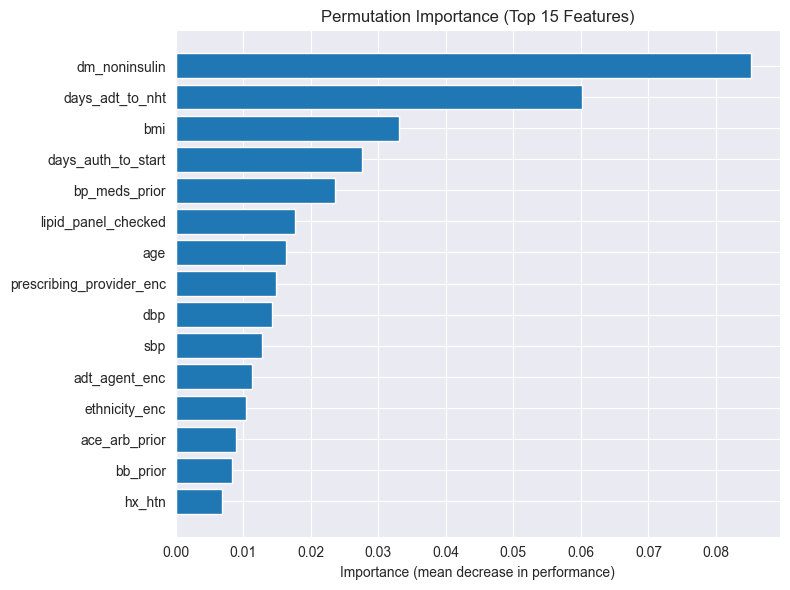

In [8]:
top15 = perm_df.head(15).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top15["feature"], top15["importance"])
plt.title("Permutation Importance (Top 15 Features)")
plt.xlabel("Importance (mean decrease in performance)")
plt.tight_layout()
plt.show()

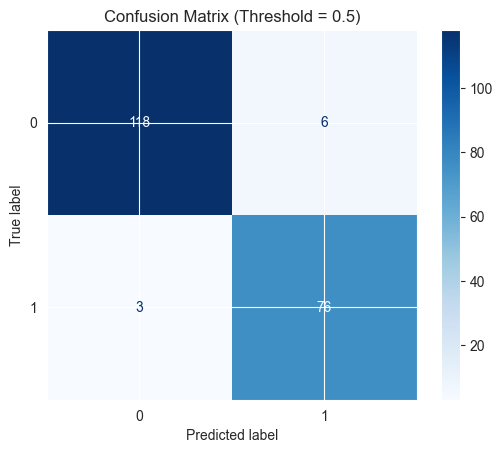

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

In [10]:
timing_cols = [
    "days_auth_to_start",
    "days_adt_to_nht"
]

X_no_timing = X.drop(columns=timing_cols, errors="ignore")

results_no_timing = cross_validate(
    rf,
    X_no_timing,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nWITH vs WITHOUT timing features:\n")

for metric in scoring:
    full = results[f"test_{metric}"].mean()
    reduced = results_no_timing[f"test_{metric}"].mean()
    print(f"{metric}: full={full:.3f}, no_timing={reduced:.3f}")


WITH vs WITHOUT timing features:

precision: full=0.492, no_timing=0.443
recall: full=0.442, no_timing=0.456
f1: full=0.459, no_timing=0.445
roc_auc: full=0.612, no_timing=0.595


In [11]:
# Get top 15 features from permutation importance
top15_features = perm_df.head(8)["feature"].tolist()

print("Top 15 Features:")
print(top15_features)

# Subset X to only top 15 features
X_top15 = X[top15_features]

print(X_top15.shape)

rf_top15 = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1
)

results_top15 = cross_validate(
    rf_top15,
    X_top15,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nTop 15 Feature Model Performance:\n")
for metric in scoring:
    vals = results_top15[f"test_{metric}"]
    print(f"{metric}: {vals.mean():.4f} ± {vals.std():.4f}")

print("\nFULL vs TOP 15 FEATURE MODEL:\n")

for metric in scoring:
    full = results[f"test_{metric}"].mean()
    top15 = results_top15[f"test_{metric}"].mean()
    print(f"{metric}: full={full:.3f}, top15={top15:.3f}")

Top 15 Features:
['dm_noninsulin', 'days_adt_to_nht', 'bmi', 'days_auth_to_start', 'bp_meds_prior', 'lipid_panel_checked', 'age', 'prescribing_provider_enc']
(203, 8)

Top 15 Feature Model Performance:

precision: 0.5395 ± 0.0394
recall: 0.5708 ± 0.0667
f1: 0.5514 ± 0.0298
roc_auc: 0.6962 ± 0.0168

FULL vs TOP 15 FEATURE MODEL:

precision: full=0.492, top15=0.539
recall: full=0.442, top15=0.571
f1: full=0.459, top15=0.551
roc_auc: full=0.612, top15=0.696


## Summary

We built a Random Forest classifier to predict cardiovascular risk (at_risk) in prostate cancer patients receiving novel hormonal therapy, using structured clinical, demographic, and treatment-related variables.

(203, 44)
0    124
1     79
Name: count, dtype: int64
precision: 0.4925 ± 0.0737
recall: 0.4417 ± 0.0998
f1: 0.4591 ± 0.0621
roc_auc: 0.6122 ± 0.0190
average_precision: 0.5415 ± 0.0667
accuracy: 0.6007 ± 0.0443


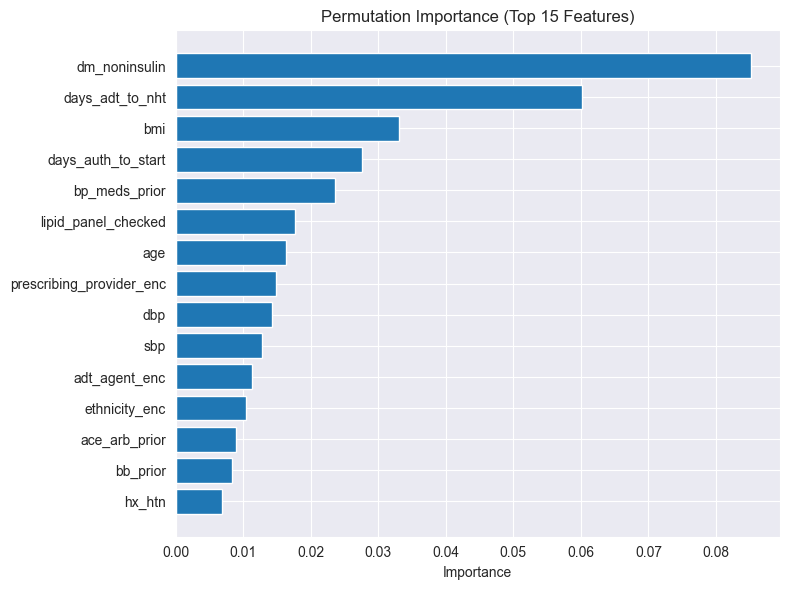

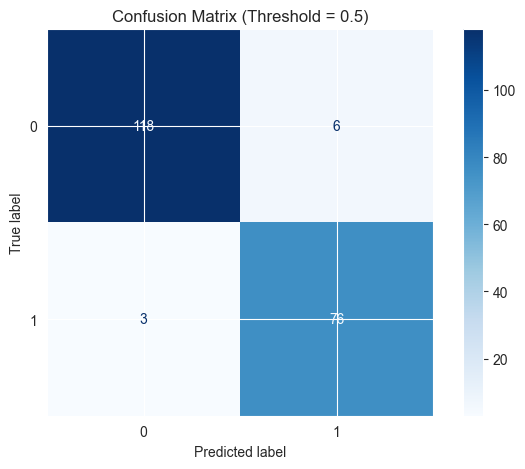


WITH vs WITHOUT timing features:

              metric      full  no_timing     delta
0          precision  0.492468   0.442566  0.049901
1             recall  0.441667   0.455833 -0.014167
2                 f1  0.459057   0.444954  0.014103
3            roc_auc  0.612179   0.594667  0.017513
4  average_precision  0.541510   0.522649  0.018860
5           accuracy  0.600732   0.566220  0.034512

FULL vs TOP FEATURE MODEL:

              metric      full  top_features     delta
0          precision  0.492468      0.539486 -0.047018
1             recall  0.441667      0.570833 -0.129167
2                 f1  0.459057      0.551369 -0.092311
3            roc_auc  0.612179      0.696242 -0.084062
4  average_precision  0.541510      0.635758 -0.094248
5           accuracy  0.600732      0.640610 -0.039878

Saved all outputs to: Results/RandomForest


In [12]:
# Random Forest

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# =========================
# OUTPUT DIR (NEW)
# =========================
OUT_DIR = "Results/RandomForest"
os.makedirs(OUT_DIR, exist_ok = True)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('../../data/processed/cardio_onc_prostate_04cleaned.csv')

n_folds = 5
seed = 42

## Data Prep

df = df[df["at_risk"].notna()].copy()

X = df.select_dtypes(include = [np.number]).drop(columns = ["at_risk", "unique_patient_id"])
y = df["at_risk"].astype(int).values

print(X.shape)
print(pd.Series(y).value_counts())

# Save dataset shape info
pd.DataFrame([{
    "n_samples": X.shape[0],
    "n_features": X.shape[1],
    "positive_rate": y.mean()
}]).to_csv(os.path.join(OUT_DIR, "data_summary.csv"), index = False)

## Random Forest Model

rf = RandomForestClassifier(
    random_state = seed,
    n_estimators = 300,
    min_samples_leaf = 5,
    min_samples_split = 10,
    max_features = 'sqrt',
    class_weight = 'balanced',
    n_jobs = -1
)

### Stratified K-Fold Cross Validation

from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = seed)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',  # PR-AUC
    'accuracy': 'accuracy'
}
results = cross_validate(
    rf,
    X,
    y,
    cv = cv,
    scoring = scoring,
    n_jobs = -1
)

# =========================
# SAVE CV RESULTS
# =========================
cv_summary = pd.DataFrame({
    metric: [results[f"test_{metric}"].mean(),
             results[f"test_{metric}"].std()]
    for metric in scoring
}, index = ["mean", "std"]).T

cv_summary.to_csv(os.path.join(OUT_DIR, "cv_results.csv"))

for metric in scoring:
    vals = results[f"test_{metric}"]
    print(f"{metric}: {vals.mean():.4f} ± {vals.std():.4f}")

## Fit Final Model

rf.fit(X, y)

## Feature Importance

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending = False)

importance_df.to_csv(os.path.join(OUT_DIR, "feature_importance.csv"), index = False)

perm_importance = permutation_importance(
    rf,
    X,
    y,
    n_repeats = 10,
    random_state = seed,
    n_jobs = -1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values("importance", ascending = False)

perm_df.to_csv(os.path.join(OUT_DIR, "permutation_importance.csv"), index = False)

## Plot Permutation Importance

top15 = perm_df.head(15).sort_values("importance")

plt.figure(figsize = (8, 6))
plt.barh(top15["feature"], top15["importance"])
plt.title("Permutation Importance (Top 15 Features)")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "perm_importance.png"), dpi = 300)
plt.show()

## Confusion Matrix

y_pred = rf.predict(X)
cm = confusion_matrix(y, y_pred)

cm_df = pd.DataFrame(cm, index = ["True 0", "True 1"], columns = ["Pred 0", "Pred 1"])
cm_df.to_csv(os.path.join(OUT_DIR, "confusion_matrix.csv"))

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = "Blues")

plt.title("Confusion Matrix (Threshold = 0.5)")
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi = 300)
plt.show()

## Timing Feature Ablation

timing_cols = ["days_auth_to_start", "days_adt_to_nht"]

X_no_timing = X.drop(columns = timing_cols, errors = "ignore")

results_no_timing = cross_validate(
    rf,
    X_no_timing,
    y,
    cv = cv,
    scoring = scoring,
    n_jobs = -1
)

timing_ablation = []

for metric in scoring:
    full = results[f"test_{metric}"].mean()
    reduced = results_no_timing[f"test_{metric}"].mean()

    timing_ablation.append({
        "metric": metric,
        "full": full,
        "no_timing": reduced,
        "delta": full - reduced
    })

timing_df = pd.DataFrame(timing_ablation)
timing_df.to_csv(os.path.join(OUT_DIR, "timing_ablation.csv"), index = False)

print("\nWITH vs WITHOUT timing features:\n")
print(timing_df)

## Top Feature Model

top_features = perm_df.head(8)["feature"].tolist()

X_top15 = X[top_features]

rf_top = RandomForestClassifier(
    random_state = seed,
    n_estimators = 300,
    min_samples_leaf = 5,
    min_samples_split = 10,
    max_features = 'sqrt',
    class_weight = 'balanced',
    n_jobs = -1
)

results_top = cross_validate(
    rf_top,
    X_top15,
    y,
    cv = cv,
    scoring = scoring,
    n_jobs = -1
)

top_vs_full = []

for metric in scoring:
    full = results[f"test_{metric}"].mean()
    top = results_top[f"test_{metric}"].mean()

    top_vs_full.append({
        "metric": metric,
        "full": full,
        "top_features": top,
        "delta": full - top
    })

top_vs_full_df = pd.DataFrame(top_vs_full)
top_vs_full_df.to_csv(os.path.join(OUT_DIR, "top_vs_full.csv"), index = False)

print("\nFULL vs TOP FEATURE MODEL:\n")
print(top_vs_full_df)

## Save Model Metadata

meta = pd.DataFrame([{
    "model": "RandomForest",
    "n_estimators": 300,
    "min_samples_leaf": 5,
    "min_samples_split": 10,
    "max_features": "sqrt",
    "n_features": X.shape[1],
    "n_samples": X.shape[0],
}])

meta.to_csv(os.path.join(OUT_DIR, "model_metadata.csv"), index = False)

print(f"\nSaved all outputs to: {OUT_DIR}")

In [13]:
# =========================
# SAVE "COEFFICIENT-LIKE" TABLE (FOR MODEL COMPARISON HEATMAPS)
# =========================

# 1. Gini importance (tree-based "coefficients")
gini_coef = pd.DataFrame({
    "feature": X.columns,
    "coefficient": rf.feature_importances_,
    "type": "gini_importance"
})

# 2. Permutation importance (preferred analogue to coefficients)
perm_coef = perm_df[["feature", "importance"]].rename(
    columns={"importance": "coefficient"}
)
perm_coef["type"] = "permutation_importance"

# 3. Combine both so you can switch in heatmaps later
rf_coefficients = pd.concat([gini_coef, perm_coef], ignore_index=True)

# Save
rf_coefficients.to_csv(
    os.path.join(OUT_DIR, "rf_coefficients_all.csv"),
    index=False
)

print(f"Saved coefficient-style table → {OUT_DIR}/rf_coefficients_all.csv")

Saved coefficient-style table → Results/RandomForest/rf_coefficients_all.csv
